In [1]:
import stable_worldmodel as swm
from stable_worldmodel.policy import PlanConfig, WorldModelPolicy
from stable_worldmodel.solver import CEMSolver
from stable_worldmodel.wm.utils import load_pretrained
from random import randint
import torch
import cv2
import gymnasium as gym              
from PIL import Image
from cem import CEM
from omegaconf import OmegaConf
from IPython.display import display

In [56]:
!hf download quentinll/lewm-tworooms --local-dir ./hf_tworoom

/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/lance/__init__.py:320: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(
/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/pty.py:89: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  pid, fd = os.forkpty()
Exception in thread /Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/lance/__init__.py:320: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(


Fetching 4 files: 100%|██████████████████████████| 4/4 [00:00<00:00, 18.10it/s]
Download complete: 100%|██████████████████| 1.31k/1.31k [00:00<00:00, 5.95kB/s]✓ Downloaded
  path: /Users/matheoledevehat/Code/leworldmodel/hf_tworoom
Traceback (most recent call last):
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/bin/hf", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/huggingface_hub/cli/hf.py", line 114, in main
    app()
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/typer/main.py", line 1154, in __call__
    raise e
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/typer/main.py", line 1137, in __call__
    return get_command(self)(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/typer/_click/core.py", line 807, 

In [3]:
import json, torch, stable_pretraining as spt
from pathlib import Path
from jepa import JEPA
from module import ARPredictor, Embedder, MLP
import stable_worldmodel as swm

src = Path("./hf_tworoom")
out = Path("./hf_tworoom", "lewm_object.ckpt")

cfg = json.loads((src / "config.json").read_text())
encoder = spt.backbone.utils.vit_hf(
    cfg["encoder"]["size"],
    patch_size=cfg["encoder"]["patch_size"],
    image_size=cfg["encoder"]["image_size"],
    pretrained=False, use_mask_token=False,
)
mlp = lambda k: MLP(input_dim=cfg[k]["input_dim"], output_dim=cfg[k]["output_dim"],
                    hidden_dim=cfg[k]["hidden_dim"], norm_fn=torch.nn.BatchNorm1d)
model = JEPA(
    encoder=encoder,
    predictor=ARPredictor(**cfg["predictor"]),
    action_encoder=Embedder(**cfg["action_encoder"]),
    projector=mlp("projector"),
    pred_proj=mlp("pred_proj"),
)
sd = torch.load(src / "weights.pt", map_location="cpu", weights_only=False)

translated_sd = {}
for key, value in sd.items():
    # 1. Fix the layer prefix
    new_key = key.replace("encoder.encoder.layer.", "encoder.layers.")
    
    # 2. Fix the Attention block
    new_key = new_key.replace("attention.attention.query.", "attention.q_proj.")
    new_key = new_key.replace("attention.attention.key.", "attention.k_proj.")
    new_key = new_key.replace("attention.attention.value.", "attention.v_proj.")
    new_key = new_key.replace("attention.output.dense.", "attention.o_proj.")
    
    # 3. Fix the MLP block
    new_key = new_key.replace("intermediate.dense.", "mlp.fc1.")
    new_key = new_key.replace("output.dense.", "mlp.fc2.")
    
    # Note: layernorm_before and layernorm_after match exactly once the layer prefix is fixed!
    
    translated_sd[new_key] = value

model.load_state_dict(translated_sd, strict=True)
out.parent.mkdir(parents=True, exist_ok=True)
torch.save(model, out)

20:20:08 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}


In [5]:
cfg = OmegaConf.load("conf/config.yaml")

In [6]:
model = model.to(cfg.device)

In [7]:
dataset = swm.data.load_dataset(
    'tworooms-fov.lance',
    num_steps=2,
    frameskip=1,
    #keys_to_load=['pixels', 'action', 'state', 'target'],
)

In [8]:
episode = dataset.load_episode(99)

In [9]:
env = gym.make('swm/TwoRoom-v1', render_mode='rgb_array')

In [58]:
env.reset(options={'proprio': episode['goal_state'][0].numpy()})
goal = env.render()
env.reset(options={'proprio': episode['state'][0].numpy()})
pixels = env.render()

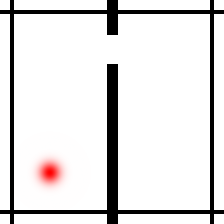

In [59]:
display(Image.fromarray(pixels))

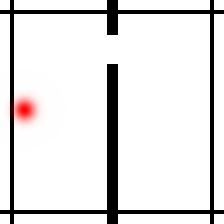

In [60]:
display(Image.fromarray(goal))

In [61]:
from torchvision.transforms import v2 as transforms
import stable_pretraining as spt

# 1. Set up the exact visual transformation used during training/eval
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(**spt.data.dataset_stats.ImageNet),
    transforms.Resize(size=224), # Match the img_size from your config
])

In [62]:
import torch
from torch.distributions.normal import Normal
from torch.linalg import vector_norm

def CEM(model, H, N, K, T, action_dim, start, goal, device, a_low, a_high, init_std_frac=0.5, min_std=1e-2, alpha=0.1):
    mean = torch.ones(H, action_dim, device=device)
    std = torch.ones(H, action_dim, device=device)
    
    goal_features = goal.reshape(1, -1)
    best_action_sequence, min_cost = None, float('inf')

    for t in range(T):
        dist = Normal(mean, std)
        candidates = dist.sample((N,))                          # (N, H, action_dim)
        candidates = candidates.clamp(a_low, a_high)   # keep in physical range

        with torch.no_grad():
            height,W,C = start.shape
            start_shaped = start.unsqueeze(0).unsqueeze(0).unsqueeze(0)
            goal_shaped = goal.unsqueeze(0).unsqueeze(0).unsqueeze(0)
            costs = model.get_cost({'pixels': start_shaped, 'goal': goal_shaped}, candidates.unsqueeze(0)).view(-1)

        #with torch.no_grad():
        #    destinations = model.rollout(model.encode_frames(start.reshape(1,1,H,W,C).transpose(-1, -3).transpose(-2, -1)), candidates, H)  # (N, D)
        #costs_2 = vector_norm(goal_features.expand(N, -1) - destinations, dim=1)

        #print(costs, costs_2)
        #assert(costs == costs_2)

        elite_costs, elite = torch.topk(costs, k=K, largest=False)
        elite_cand = candidates[elite]   # (K, H, action_dim)

        new_mean = elite_cand.mean(dim=0)
        new_std  = elite_cand.std(dim=0).clamp_min(min_std)     # variance floor

        mean = (1 - alpha) * new_mean + alpha * mean
        std  = (1 - alpha) * new_std  + alpha * std
        
        if elite_costs[0] < min_cost:
            best_action_sequence = elite_cand[0].clone()        # (H, action_dim)
            min_cost = elite_costs[0].item()

    return best_action_sequence

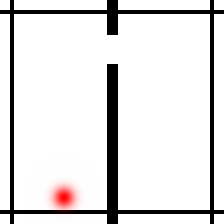

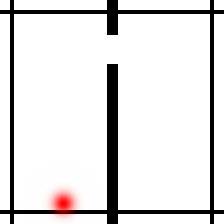

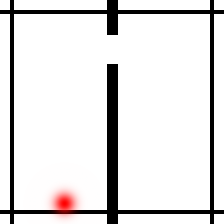

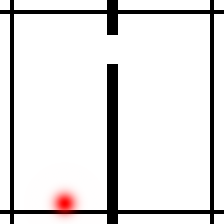

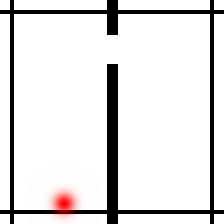

KeyboardInterrupt: 

In [63]:
a_low = -1
a_high = 1
for i in range(100):
    start_tensor = transform(pixels).to(cfg.device)
    goal_tensor = transform(goal).to(cfg.device)
    
    model.eval()
    actions = CEM(model, 2, 300, 30, 30, cfg.model.action_dim*5, start_tensor, goal_tensor, cfg.device, a_low, a_high)
    first_action_chunk = actions[0].cpu().numpy()
    
    # 2. Reshape the 10-dim chunk back into 5 environment steps of dim 2
    first_action_chunk = first_action_chunk.reshape(5, 2)
    
    # 3. Execute the 5 steps in the environment before replanning
    for act in first_action_chunk:
        env.step(act)
    pixels = env.render()
    img = Image.fromarray(pixels)
    display(img)